# Example: Building a Minimum-Variance Portfolio with Hybrid Forward Simulation

In this example, we assemble a minimum-variance portfolio from a user-chosen ticker list by loading the SIM parameters calibrated in the previous notebook, building the SIM covariance matrix on that subset, tracing the efficient frontier, and then forward-simulating the chosen allocation with the hybrid [JumpHMM](https://github.com/varnerlab/JumpHMM.jl) construction. We hold the allocation buy-and-hold over the horizon across many synthetic futures and summarize the outcome as a distributional scorecard.

> __Learning Objectives:__
>
> * __Calibrated SIM portfolios:__ We load pre-computed SIM regression parameters for a user-chosen ticker subset from the S&P 500 calibration and build the SIM covariance matrix and expected growth rate vector on that subset. We solve the minimum-variance allocation problem at a target return and trace the full efficient frontier to see how the risk-return trade-off evolves.
> * __Hybrid forward simulation with regime structure:__ We compose synthetic market futures from a regime-switching market model, per-ticker idiosyncratic draws, and a Student-t copula that enforces realistic cross-sectional dependence. The resulting scenarios carry fat tails, volatility clustering, and regime shifts that a Gaussian Single Index Model cannot reproduce.
> * __Distributional scorecard replaces point estimates:__ We hold the chosen allocation buy-and-hold across every simulated path and summarize the outcome distribution through median terminal wealth, percentile spreads, maximum drawdown, Sharpe ratio, and two failure rates. Portfolio quality is judged as a full distribution over synthetic futures rather than a single point estimate.

Let's get started!
___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via the `Include.jl` file. This activates the local Julia environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants


In [2]:
# --- Portfolio universe ---
# Load the ticker universe from data/my-tickers.csv. To change the universe,
# edit that file directly (see lets_find_my_tickers.md for the procedure).
# Every ticker must exist in MySIMCalibration()["tickers"].
tickers_df = CSV.read(joinpath(_PATH_TO_DATA, "my-tickers.csv"), DataFrame);
my_tickers = String.(tickers_df.ticker);
N          = nrow(tickers_df);

# --- Portfolio configuration ---
# Load budget, risk-free rate, target growth, and concentration cap from portfolio-config.toml.
cfg        = TOML.parsefile(joinpath(_PATH_TO_DATA, "portfolio-config.toml"));
B₀         = Float64(cfg["portfolio"]["initial_budget"]);
g_f        = Float64(cfg["portfolio"]["risk_free_rate"]);
R_target   = Float64(cfg["portfolio"]["target_growth"]);
max_weight = Float64(get(cfg["portfolio"], "max_weight", 1.0));
@assert max_weight >= 1.0/N "max_weight = $(max_weight) is infeasible for N = $(N) tickers (need >= $(round(1/N, digits=3)))"

# --- Forward simulation parameters ---
n_paths  = 500;            # number of forward Monte Carlo paths
n_steps  = 252;            # horizon in trading days (1 year)
Δt       = 1.0 / 252.0;    # daily time step (years)

# --- Optional custom allocation override ---
# Leave as nothing to use the minimum-variance QP weights at R_target.
# Set to a Vector{Float64} of length N that sums to 1 to override.
my_weights = nothing;

println("Universe: $(N) tickers loaded from my-tickers.csv")
println("  $(my_tickers)")
println("Budget: \$$(Int(B₀))")
println("Horizon: $(n_steps) days, $(n_paths) Monte Carlo paths, R_target = $(round(R_target*100, digits=1))%/yr")
println("Risk-free baseline: $(round(g_f*100, digits=2))%/yr (continuous compounding)")
println("Concentration cap: max_weight = $(round(max_weight*100, digits=1))% per ticker")

Universe: 22 tickers loaded from my-tickers.csv


  ["DIS", "NFLX", "AMZN", "HD", "TJX", "COST", "CVX", "JPM", "V", "MA", "UNH", "LLY", "ABBV", "HON", "CAT", "AAPL", "MSFT", "NVDA", "AVGO", "CRM", "SHW", "AMT"]
Budget: $100000
Horizon: 252 days, 500 Monte Carlo paths, R_target = 10.0%/yr
Risk-free baseline: 4.5%/yr (continuous compounding)
Concentration cap: max_weight = 20.0% per ticker


___
## Task 1: Build the Minimum-Variance Portfolio from Calibrated SIM
We pick a small ticker subset, load the SIM parameters calibrated in the [SIM parameter estimation notebook](eCornell-AI-Finance-S1-Example-SIMParameterEstimation-May-2026.ipynb), assemble the SIM covariance matrix, solve the minimum-variance QP at our chosen target return, sweep the frontier, and resolve the final allocation that we will forward-simulate in Task 2.

> __What are we going to do?__
>
> Configure the universe and the QP target return, load real-data $\alpha_i$, $\beta_i$, and $\sigma_{\varepsilon,i}$ for that subset from the cached SIM calibration, build the SIM covariance matrix $\Sigma$ via [the `build_sim_covariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build_sim_covariance), solve the minimum-variance QP with [the `solve_minvariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.solve_minvariance), sweep the target return $R$ to draw the efficient frontier, and pull the resulting weights into `allocation_weights::Vector{Float64}`. The `my_weights = nothing` slot lets you override the QP solution with a custom vector if you want to forward-simulate a non-optimal allocation instead.
>
> The SIM parameters come from [the `MySIMCalibration()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMCalibration), which returns a `Dict` with $\alpha$, $\beta$, $\sigma_\varepsilon$, and $R^2$ for every ticker in the S&P 500 calibration universe, fitted from 2014 to 2024 VWAP data by regressing each ticker's annualized growth rate on SPY. All quantities are in **annualized growth-rate units (1/year)**: $\alpha$ is a per-year drift, $\sigma_\varepsilon$ is the standard deviation of the annualized residual growth rate, and the market volatility $\sigma_m$ is the sample standard deviation of SPY's annualized growth rates.

The code below loads the calibration, extracts the subset for `my_tickers`, builds a vector of [`MySIMParameterEstimate`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMParameterEstimate) objects, pulls `σ_m::Float64`, and displays a summary table.

In [3]:
sim_estimates, σ_m, sim_calibration = let

    # --- Step 1: Load the SIM parameter estimates (saved by the SIM notebook) ---
    sim_data = load_results(joinpath(_PATH_TO_DATA, "sim-parameter-estimates.jld2"));
    all_estimates = sim_data["sim_estimates"];
    est_lookup = Dict{String, MySIMParameterEstimate}();
    for est ∈ all_estimates
        est_lookup[est.ticker] = est;
    end

    # --- Step 2: Validate that every user ticker is present ---
    missing = [t for t ∈ my_tickers if !haskey(est_lookup, t)];
    @assert isempty(missing) "Tickers not in SIM estimates: $(missing)"

    # --- Step 3: Extract the subset for our universe ---
    estimates = [est_lookup[t] for t ∈ my_tickers];

    # --- Step 4: Market volatility ---
    σm = sim_data["sigma_market"];

    # --- Step 5: Display the calibrated parameters for the subset ---
    df = DataFrame(
        "Ticker" => [e.ticker for e ∈ estimates],
        "α (%/yr)" => [round(e.α * 100, digits=2) for e ∈ estimates],
        "β" => [round(e.β, digits=3) for e ∈ estimates],
        "σ_ε grow (%/yr)" => [round(e.σ_ε * 100, digits=1) for e ∈ estimates],
        "σ_ε vol (%/yr)"  => [round(e.σ_ε / sqrt(252) * 100, digits=2) for e ∈ estimates],
        "R²" => [round(e.r², digits=3) for e ∈ estimates]
    );
    println("SIM parameters for $(length(estimates)) tickers:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    println("Market σ_m (1/year): $(round(σm, digits=4))  "
            * "→ growth %/yr: $(round(σm*100, digits=1))%  "
            * "fin vol %/yr: $(round(σm/sqrt(252)*100, digits=2))%")

    estimates, σm, sim_data
end;

SIM parameters for 22 tickers:


 -------- ---------- --------- ----------------- ---------------- ---------
  Ticker   α (%/yr)         β   σ_ε grow (%/yr)   σ_ε vol (%/yr)        R² 
  String    Float64   Float64           Float64          Float64   Float64 
 -------- ---------- --------- ----------------- ---------------- ---------
     DIS      -8.55     1.131             321.3            20.24     0.547
    NFLX      13.23     1.201             637.9            40.19     0.257
    AMZN       8.77     1.231             369.4            23.27      0.52
      HD       3.09     1.048             242.1            15.25     0.646
     TJX       0.97     1.052             315.7            19.89      0.52
    COST      11.03     0.727             262.7            16.55     0.428
     CVX      -9.56     1.029             337.1            21.24     0.476
     JPM       0.06     1.203             263.0            16.57     0.671
       V       3.99     1.122             207.9            13.09      0.74
      MA       4.27  

The minimum-variance QP needs the vector of expected asset growth rates $\mathbb{E}[\mathbf{g}] = [\mathbb{E}[g_i]]$ with $\mathbb{E}[g_i] = \alpha_i + \beta_i \cdot \mathbb{E}[g_{\mathrm{mkt}}]$, where $\mathbb{E}[g_{\mathrm{mkt}}]$ is the expected market growth rate. We pull $\mathbb{E}[g_{\mathrm{mkt}}]$ from [the `MySyntheticTrainingDataSet()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySyntheticTrainingDataSet), which stores the mean of the frozen synthetic market path, and assemble the result into `Eg_vec::Vector{Float64}` (annualized, 1/year).

In [4]:
Eg_mkt, Eg_vec = let
    # --- Step 1: Expected market growth rate from the synthetic training dataset ---
    ds = MySyntheticTrainingDataSet();
    Egmkt = mean(ds["market_returns"]);      # 1/year

    # --- Step 2: SIM expected growth rate per ticker: E[g_i] = α_i + β_i · E[g_mkt] ---
    Eg = [est.α + est.β * Egmkt for est ∈ sim_estimates];

    println("E[g_mkt] (annualized market growth rate): $(round(Egmkt*100, digits=2))%/yr")
    println("E[g] range across user tickers: "
            * "[$(round(minimum(Eg)*100, digits=2))%, $(round(maximum(Eg)*100, digits=2))%]/yr")

    Egmkt, Eg
end;

E[g_mkt] (annualized market growth rate): 7.93%/yr


E[g] range across user tickers: [-1.4%, 48.55%]/yr


With the SIM parameters in hand we build the covariance matrix, solve the QP at the target return, and sweep `R` to trace the entire efficient frontier.

> __SIM Covariance Matrix:__
>
> [The `build_sim_covariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build_sim_covariance) assembles the covariance matrix of annualized growth rates directly from the SIM parameters. The off-diagonal entries $\Sigma_{ij} = \beta_i \beta_j \sigma_m^2$ capture pure market co-movement between assets $i$ and $j$, while the diagonal entries $\Sigma_{ii} = \beta_i^2 \sigma_m^2 + \sigma_{\varepsilon,i}^2$ add each asset's firm-specific residual variance on top of its market component. All entries are in $(1/\text{year})^2$. The key payoff is structural: the SIM covariance has only $N + 1$ free parameters (the $N$ betas plus the market variance) instead of the $N(N+1)/2$ of a sample covariance, which keeps optimization tractable on large universes and avoids the noise that full sample covariance matrices accumulate from short data windows.
>
> With the covariance in hand, we build the problem via [the `build(...)` factory](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build-Tuple{Type{MyPortfolioAllocationProblem}}), solve it with [the `solve_minvariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.solve_minvariance), then sweep the target return `R` to plot the efficient frontier and mark the chosen target.

The code below computes the covariance matrix, solves the minimum-variance QP, and stores the solver output in `minvar_result::MyPortfolioPerformanceResult`.


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



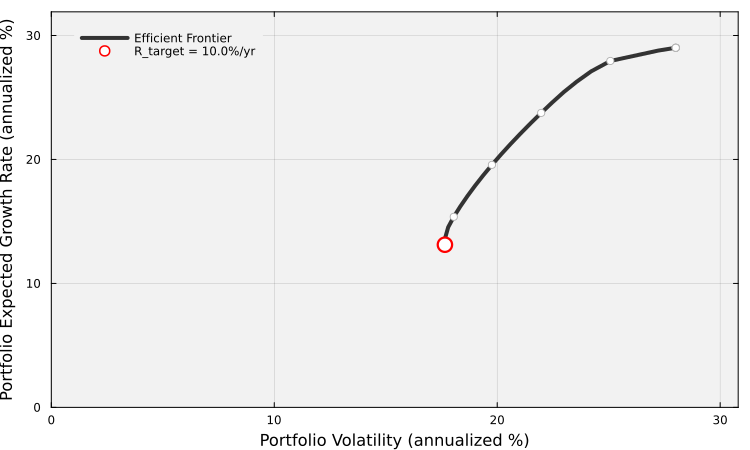

Chosen portfolio: expected growth rate 13.12%/yr, volatility 17.65%/yr (finance convention)


In [5]:
minvar_result = let

    # --- Step 1: Build the SIM covariance matrix (units: 1/year²) ---
    Σ = build_sim_covariance(sim_estimates, σ_m);

    # --- Step 2: Long-only bounds and the QP ---
    bounds = hcat(zeros(N), fill(max_weight, N));
    problem = build(MyPortfolioAllocationProblem;
        μ = Eg_vec, Σ = Σ, bounds = bounds, R = R_target);

    # --- Step 3: Solve the minimum-variance QP at the target return ---
    mv = solve_minvariance(problem);

    # --- Step 4: Sweep the target return to trace the efficient frontier ---
    R_grid = range(minimum(Eg_vec) + 1e-4, 0.99 * maximum(Eg_vec), length = 60) |> collect;
    frontier_σ = Float64[];
    frontier_Eg = Float64[];
    for R_i ∈ R_grid
        try
            prob_i = build(MyPortfolioAllocationProblem;
                μ = Eg_vec, Σ = Σ, bounds = bounds, R = R_i);
            sol = solve_minvariance(prob_i);
            σ_p = sqrt(sol.variance) / sqrt(252) * 100;  # finance vol %/yr
            Eg_p = sol.expected_return * 100;             # %/yr
            push!(frontier_σ, σ_p);
            push!(frontier_Eg, Eg_p);
        catch
            # infeasible, skip
        end
    end

    # --- Step 5: Plot the efficient frontier and mark the chosen target ---
    chosen_σ = sqrt(mv.variance) / sqrt(252) * 100;
    chosen_Eg = mv.expected_return * 100;
    max_σ = maximum(frontier_σ);
    max_Eg = maximum(frontier_Eg);
    skip = 5;

    p = plot(frontier_σ, frontier_Eg,
        lw = 4, c = :gray20, label = "Efficient Frontier",
        xlabel = "Portfolio Volatility (annualized %)",
        ylabel = "Portfolio Expected Growth Rate (annualized %)",
        fontsize = 18,
        xlim = (0.0, 1.1 * max_σ),
        ylim = (0.0, 1.1 * max_Eg),
        size = (750, 450));
    scatter!(p, frontier_σ[1:skip:end], frontier_Eg[1:skip:end],
        label = "", c = :white, ms = 4, msc = :gray69);
    scatter!(p, [chosen_σ], [chosen_Eg],
        marker = :circle, ms = 8, c = :white, msc = :red, msw = 2.5,
        label = "R_target = $(round(R_target*100, digits=1))%/yr");
    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft);

    display(p)
    println("Chosen portfolio: expected growth rate $(round(chosen_Eg, digits=2))%/yr, "
            * "volatility $(round(chosen_σ, digits=2))%/yr (finance convention)")

    mv
end;

The allocation we will forward-simulate is either the minimum-variance QP solution (default) or the `my_weights` override if set in Task 1. The code below resolves the final weight vector into `allocation_weights::Vector{Float64}` and displays it as a table.

In [6]:
allocation_weights = let
    # --- Step 1: Resolve weights (QP default vs user override) ---
    w = isnothing(my_weights) ? minvar_result.weights : Float64.(my_weights);
    @assert length(w) == N "my_weights length must equal number of tickers"
    @assert isapprox(sum(w), 1.0; atol=1e-6) "my_weights must sum to 1"

    # --- Step 2: Display the weights as a table ---
    # Helper: round then clamp "-0.0" to "+0.0" for display -
    rnz(x, d) = begin
        r = round(x, digits=d);
        r == 0.0 ? 0.0 : r;
    end;
    df = DataFrame(
        "Ticker" => my_tickers,
        "Weight (%)" => [rnz(wi * 100, 2) for wi ∈ w]
    );
    println("Allocation to forward-simulate:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    w
end;

Allocation to forward-simulate:
 -------- ------------
  Ticker   Weight (%) 
  String      Float64 
 -------- ------------
     DIS          0.0
    NFLX          0.0
    AMZN          0.0
      HD         2.35
     TJX         1.07
    COST         20.0
     CVX         2.47
     JPM          0.0
       V          0.0
      MA          0.0
     UNH        11.64
     LLY        17.33
    ABBV        17.73
     HON          0.0
     CAT          0.0
    AAPL          0.0
    MSFT          0.0
    NVDA          0.0
    AVGO          0.0
     CRM          0.0
     SHW         7.41
     AMT         20.0
 -------- ------------


___
## Task 2: Forward-Simulate the Allocation with Hybrid JumpHMM
We resolve realistic starting prices for each ticker, generate many synthetic futures via the hybrid SIM construction, and visualize a sample of the resulting wealth trajectories before scoring them quantitatively in Task 3.

> __What are we going to do?__
>
> Pull last-day closes from [the `MyCurrentPrices()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyCurrentPrices) so the simulated price paths begin at realistic levels, then call [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) to produce `n_paths` Monte Carlo futures composed of a JumpHMM market path, per-ticker HMM idiosyncratic draws (R²-preserving or variance-correcting), and Student-t copula rank-reordering. Visualize sample buy-and-hold wealth trajectories with the median across all paths overlaid.

The starting price for each ticker is the price each ticker has on the first simulated trading day, which determines how many shares the buy-and-hold engine purchases for the given allocation. The `start_prices::Dict{String,Float64}` dictionary built below caches the last available real daily close from the testing OHLC dataset (Polygon S&P 500 data through 2025-12-31) and is handed to the hybrid scenario generator so the simulated price paths begin at realistic levels.

In [7]:
start_prices = let
    snap = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    sp = Dict{String, Float64}()
    for t ∈ my_tickers
        @assert haskey(snap_lookup, t) "Ticker $(t) not in MyCurrentPrices() snapshot"
        sp[t] = snap_lookup[t];
    end

    # --- Compute initial position: shares and dollar value per ticker ---
    # shares_i = (B₀ * w_i) / P_i  (fractional shares permitted)
    # dollar_i = shares_i * P_i = B₀ * w_i
    prices_vec  = [sp[t] for t ∈ my_tickers];
    dollars_vec = B₀ .* allocation_weights;
    shares_vec  = dollars_vec ./ prices_vec;

    println("Starting prices and initial position for forward simulation (from $(snap["source_label"])):")
    # Helper: round then clamp "-0.0" to "+0.0" for display -
    # (round() on small negatives returns -0.0, which prints with a minus sign)
    rnz(x, d) = begin
        r = round(x, digits=d);
        r == 0.0 ? 0.0 : r;
    end;

    df = DataFrame(
        "Ticker"         => my_tickers,
        "Price (\$)"     => [rnz(p, 2) for p ∈ prices_vec],
        "Weight (%)"     => [rnz(w * 100, 2) for w ∈ allocation_weights],
        "Shares"         => [rnz(s, 4) for s ∈ shares_vec],
        "Dollar Value"   => [rnz(d, 2) for d ∈ dollars_vec],
        "As of"          => [snap["last_dates"][findfirst(==(t), snap["tickers"])] for t ∈ my_tickers],
    );
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    println("\nTotal invested: \$$(round(sum(dollars_vec), digits=2))  (= B₀ = \$$(Int(B₀)))")

    sp
end;

Starting prices and initial position for forward simulation (from polygon-ohlc-testing-dataset):


 -------- ----------- ------------ --------- -------------- ---------------------
  Ticker   Price ($)   Weight (%)    Shares   Dollar Value                 As of 
  String     Float64      Float64   Float64        Float64                String 
 -------- ----------- ------------ --------- -------------- ---------------------
     DIS      113.77          0.0       0.0            0.0   2025-12-31T05:00:00
    NFLX       93.76          0.0       0.0            0.0   2025-12-31T05:00:00
    AMZN      230.82          0.0       0.0            0.0   2025-12-31T05:00:00
      HD       344.1         2.35     6.831        2350.55   2025-12-31T05:00:00
     TJX      153.61         1.07    6.9526        1067.98   2025-12-31T05:00:00
    COST      862.34         20.0   23.1927        20000.0   2025-12-31T05:00:00
     CVX      152.41         2.47   16.2138        2471.14   2025-12-31T05:00:00
     JPM      322.22          0.0       0.0            0.0   2025-12-31T05:00:00
       V      350.71    

With the starting prices resolved we run the forward Monte Carlo. Each path composes a JumpHMM market growth-rate path with a per-ticker HMM idiosyncratic draw, scales the innovations via either the R²-preserving branch (for tickers whose real-data $R^2 \geq 0.80$) or the marginal-preserving variance correction, and rank-reorders them through the Student-t copula.

> __Hybrid SIM Forward Construction:__
>
> For each of `n_paths` simulations and each ticker in the universe, we compose
>
> $$g_i(t) = \alpha_i + \beta_i\,g_{\mathrm{mkt}}(t) + \varepsilon_i(t)$$
>
> where:
>
> * $g_{\mathrm{mkt}}(t)$ is drawn from the [JumpHMM market surrogate](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyMarketSurrogateModel) — a pre-trained model fitted on SPY with regime switching, volatility clustering, and jumps.
> * $\varepsilon_i(t)$ starts as a draw from the ticker's own HMM marginal in [the portfolio surrogate](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyPortfolioSurrogateModel), so it inherits the ticker's heavy tails and clustering. It is then scaled (variance-correcting if $R^2 < 0.80$, $R^2$-preserving otherwise) and copula rank-reordered so cross-sectional dependence matches the Student-t copula fitted on the real universe.
> * The composed growth rate is converted to a price via $S_{t+1} = S_t \exp(g_i(t)\,\Delta t)$.

[The `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) does all of the above in a single call and returns a [`MyBacktestScenario`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBacktestScenario) whose `price_paths` field has shape `(n_paths, n_steps, N)`. The code below runs the hybrid forward simulation and stores the result in `scenario::MyBacktestScenario`.

In [8]:
scenario = let
    # --- Step 1: Load the surrogate models (cached on disk) ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();

    # --- Step 2: Generate the hybrid forward scenario ---
    scen = generate_hybrid_scenario(market_model, portfolio, sim_calibration, my_tickers;
        n_paths = n_paths,
        n_steps = n_steps,
        Δt      = Δt,
        start_prices = start_prices,
        label   = "Hybrid-SIM ($(n_steps)d)",
        seed    = 2026);

    # --- Step 3: Sanity check on the output shape ---
    println("scenario.price_paths shape: $(size(scen.price_paths)) "
            * "(n_paths × n_steps × N_tickers)")
    println("scenario.market_paths shape: $(size(scen.market_paths))")

    scen
end;

scenario.price_paths shape: (500, 252, 22) (n_paths × n_steps × N_tickers)


scenario.market_paths shape: (500, 252)


Before we run the scorecard it helps to visually confirm the scenario is reasonable. The code below computes the buy-and-hold wealth trajectory for 15 sampled paths using the allocation we resolved in Task 1 and overlays the median across all paths.

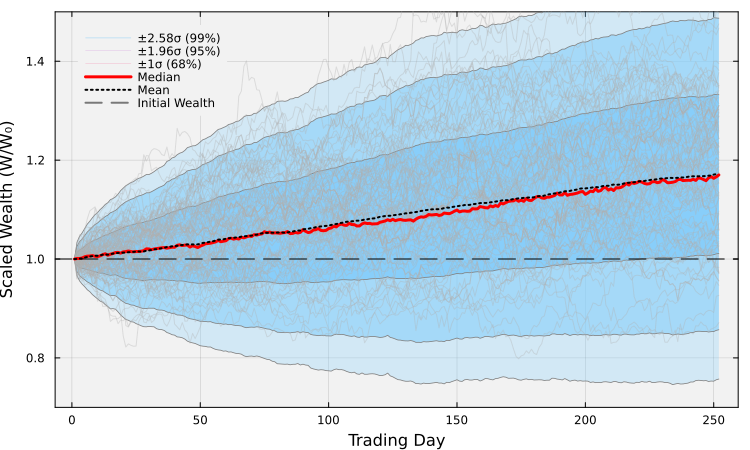

In [9]:
let
    # --- Step 1: Randomly sample paths for the spaghetti overlay ---
    Random.seed!(2027);
    sample_idx = rand(1:scenario.n_paths, 100);
    initial_wealth = B₀;

    # --- Step 2: Compute the full wealth matrix across ALL paths ---
    # wealth_all[t, p] = W(t) / W₀ for path p at time t
    N = length(my_tickers);
    wealth_all = zeros(scenario.n_steps, scenario.n_paths);
    for p ∈ 1:scenario.n_paths
        shares = [(B₀ * allocation_weights[k]) / scenario.price_paths[p, 1, k] for k in 1:N];
        for t ∈ 1:scenario.n_steps
            wealth_all[t, p] = (1/initial_wealth) * sum(shares[k] * scenario.price_paths[p, t, k] for k in 1:N);
        end
    end

    # --- Step 3: Median, mean, and std trajectory over ALL paths ---
    median_trajectory = [median(wealth_all[t, :]) for t ∈ 1:scenario.n_steps];
    mean_trajectory   = [mean(wealth_all[t, :])   for t ∈ 1:scenario.n_steps];
    std_trajectory    = [std(wealth_all[t, :])    for t ∈ 1:scenario.n_steps];

    # --- Step 4: Sampled paths for overlay (from Step 1 indices) ---
    wealth_sample = wealth_all[:, sample_idx];

    # --- Step 5: Plot ---
    days = 1:scenario.n_steps;

    # Nested confidence ribbons (99% outermost, 95% middle, 68% innermost),
    # lighter alpha as bands widen. Plot outer first so inner bands paint over.
    p = plot(days, mean_trajectory;
        ribbon = 2.58 .* std_trajectory,
        fillalpha = 0.30, fillcolor = :lightskyblue,
        lw = 0, label = "±2.58σ (99%)",
        xlabel = "Trading Day",
        ylabel = "Scaled Wealth (W/W₀)",
        fontsize = 18,
        size = (750, 450));
    plot!(p, days, mean_trajectory .+ 2.58 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 2.58 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory;
        ribbon = 1.96 .* std_trajectory,
        fillalpha = 0.60, fillcolor = :lightskyblue,
        lw = 0, label = "±1.96σ (95%)");
    plot!(p, days, mean_trajectory .+ 1.96 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 1.96 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory;
        ribbon = 1.00 .* std_trajectory,
        fillalpha = 0.95, fillcolor = :lightskyblue,
        lw = 0, label = "±1σ (68%)");
    plot!(p, days, mean_trajectory .+ 1.00 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 1.00 .* std_trajectory;
        lw = 0.8, c = :gray50, label = "");

    # Spaghetti overlay of sampled paths
    plot!(p, days, wealth_sample;
        lw = 1, c = :gray69, alpha = 0.35, label = "");

    # Median and mean lines
    plot!(p, days, median_trajectory;
        lw = 3, c = :red, label = "Median");
    plot!(p, days, mean_trajectory;
        lw = 2, ls = :dot, c = :black, label = "Mean");

    # Break-even reference
    hline!(p, [1.0];
        lw = 2, ls = :dash, c = :black, alpha = 0.5, label = "Initial Wealth");

    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft,
        ylims = (0.70, 1.50));
    display(p)
end;

___
## Task 3: Score the Distribution and Hand Off
We hold the allocation buy-and-hold across every simulated path, summarize the resulting distribution of outcomes (terminal wealth, max drawdown, Sharpe ratio, fail rate), visualize the spread with histograms, and persist the allocation plus scorecard to disk so downstream stress-test notebooks can load it directly.

> __Scorecard:__
>
> A scorecard condenses thousands of Monte Carlo paths into a handful of numbers that describe the full distribution of outcomes, not just a single point estimate. Several definitions are worth stating up front. For any per-path quantity $X^{(p)}$ collected across the $M$ simulated paths $p = 1, \ldots, M$, the **median** is the 50th-percentile value (the middle outcome when paths are ordered), and the **$q$-th percentile** $P_q$ is the value below which fraction $q/100$ of paths fall. The **peak-to-trough drawdown** on a single wealth path $W^{(p)}_t$ is $\max_{s \leq t}\{(W^{(p)}_s - W^{(p)}_t)/W^{(p)}_s\}$, and the **per-path Sharpe ratio** is $(\bar{r}^{(p)} - g_f)/\hat{\sigma}^{(p)}$ where $\bar{r}^{(p)}$ is the sample mean return and $\hat{\sigma}^{(p)}$ the sample volatility along path $p$.
>
> The scorecard reports four metric families. The **terminal wealth distribution** is summarized by the median $W_T$ together with $P_{10}$ (10th percentile, a pessimistic-tail benchmark) and $P_{90}$ (90th percentile, an optimistic-tail benchmark); the width $P_{90} - P_{10}$ is a proxy for the spread of plausible futures. The **median max drawdown** and **median Sharpe ratio** are medians over per-path drawdown and Sharpe values as defined above.
>
> Two failure-rate metrics sit alongside these. The nominal **fail rate** $P[W_T < B_0]$ is the fraction of paths that ended below the initial wealth $B_0$, answering the blunt question "what is the chance I lose money". The economically meaningful alternative is the **NPV-fail rate** $P[\text{NPV} < 0]$, the fraction of paths where the portfolio underperformed the continuously compounded risk-free baseline. The NPV itself is defined per path as $\text{NPV}^{(p)}(g_f, T) = -B_0 + W_{\mathcal{P}}^{(p)}(T)\,e^{-g_f T}$, the present-value excess wealth after discounting at the risk-free growth rate $g_f$; its median complements the median terminal wealth and is our primary deployment-readiness metric. For the formal definition see [the Portfolio NPV section of the Session 1 lecture](eCornell-AI-Finance-S1-Lecture-StressTestingMinVariancePortfolios-May-2026.ipynb).
>
> To compute these metrics we use [the `backtest_buyhold(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_buyhold), which takes the scenario, the tickers, the initial wealth, and the weight vector, and returns a [`MyBacktestResult`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBacktestResult) with per-path terminal wealth, drawdown, and Sharpe arrays. We pass `offset = 1` because the buy happens on day 1 (no warm-up period in this notebook).

The code below runs the buy-and-hold engine and stores the result in `result::MyBacktestResult`.

In [10]:
result = let
    # --- Step 1: Run buy-and-hold across every path ---
    r = backtest_buyhold(scenario, my_tickers;
        B₀      = B₀,
        offset  = 1,                      # buy on day 1
        weights = allocation_weights);

    # --- Step 2: Per-path NPV against the continuously compounded risk-free baseline ---
    # NPV(g_f, T) = -B₀ + W_T · e^(-g_f · T)   (in today's dollars)
    T_years = scenario.n_steps / 252;
    npv     = r.final_wealth .* exp(-g_f * T_years) .- B₀;

    # --- Step 3: Summarize the terminal wealth / drawdown / Sharpe / NPV distributions ---
    scorecard = DataFrame(
        "Metric" => [
            "Median terminal wealth",
            "P10 terminal wealth",
            "P90 terminal wealth",
            "Median max drawdown",
            "Median Sharpe ratio",
            "Fail rate P[W_T < B₀]",
            "Median NPV vs risk-free",
            "NPV-fail rate P[NPV < 0]"
        ],
        "Units" => [
            "W_T / B₀",
            "W_T / B₀",
            "W_T / B₀",
            "%",
            "dimensionless",
            "%",
            "USD",
            "%"
        ],
        "Value" => [
            round(median(r.final_wealth) / B₀, digits=3),
            round(quantile(r.final_wealth, 0.10) / B₀, digits=3),
            round(quantile(r.final_wealth, 0.90) / B₀, digits=3),
            round(median(r.max_drawdowns) * 100, digits=2),
            round(median(r.sharpe_ratios), digits=3),
            round(mean(r.final_wealth .< B₀) * 100, digits=1),
            round(median(npv), digits=0),
            round(mean(npv .< 0) * 100, digits=1)
        ]
    );

    println("Buy-and-hold scorecard over $(scenario.n_paths) paths, $(scenario.n_steps)-day horizon:")
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    r
end;

Buy-and-hold scorecard over 500 paths, 252-day horizon:


 -------------------------- --------------- ---------
                    Metric           Units     Value 
                    String          String   Float64 
 -------------------------- --------------- ---------
    Median terminal wealth        W_T / B₀      1.17
       P10 terminal wealth        W_T / B₀      0.97
       P90 terminal wealth        W_T / B₀      1.37
       Median max drawdown               %     14.05
       Median Sharpe ratio   dimensionless     0.899
     Fail rate P[W_T < B₀]               %      14.2
   Median NPV vs risk-free             USD   11860.0
  NPV-fail rate P[NPV < 0]               %      23.2
 -------------------------- --------------- ---------


The histograms below show the distributions across paths with the median marked on each.

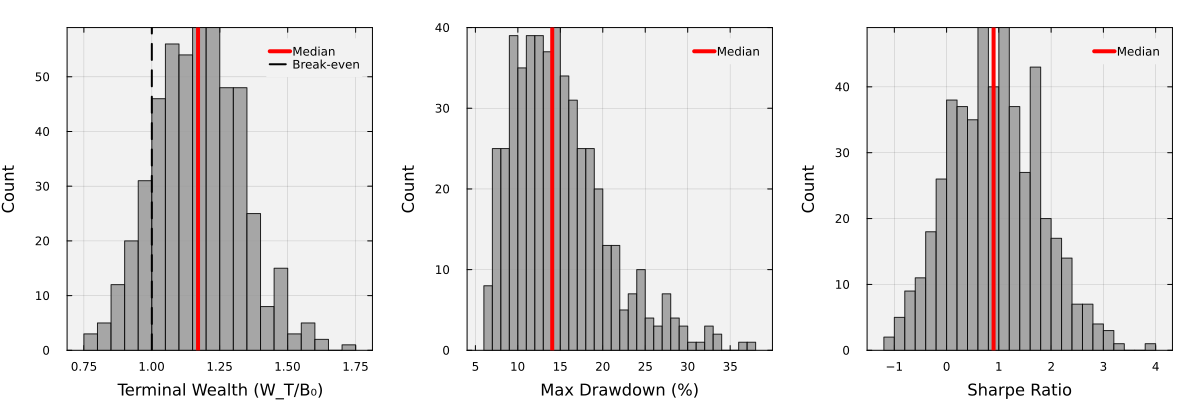

In [11]:
let
    scaled_wealth = result.final_wealth ./ B₀;
    median_wealth = median(scaled_wealth);
    median_dd     = median(result.max_drawdowns);
    median_sharpe = median(result.sharpe_ratios);

    # --- Panel 1: Scaled terminal wealth ---
    p1 = histogram(scaled_wealth, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Terminal Wealth (W_T/B₀)", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p1, [median_wealth], lw = 4, c = :red, label = "Median");
    vline!(p1, [1.0], lw = 2, ls = :dash, c = :black, label = "Break-even");
    plot!(p1, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    # --- Panel 2: Max drawdown ---
    p2 = histogram(result.max_drawdowns .* 100, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Max Drawdown (%)", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p2, [median_dd * 100], lw = 4, c = :red, label = "Median");
    plot!(p2, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    # --- Panel 3: Sharpe ratio ---
    p3 = histogram(result.sharpe_ratios, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Sharpe Ratio", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p3, [median_sharpe], lw = 4, c = :red, label = "Median");
    plot!(p3, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    plot(p1, p2, p3, layout = (1, 3), size = (1200, 400), margin = 5Plots.mm)
end

Finally we persist the allocation, SIM parameters, and the scorecard arrays to disk. The next notebook in this sequence (Stress-Test) will load this file directly instead of re-solving the QP. The code below saves the handoff file using [the `save_results(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.save_results).

In [12]:
let
    save_path = joinpath(_PATH_TO_DATA, "minvar-allocation.jld2");
    T_years = scenario.n_steps / 252;
    npv     = result.final_wealth .* exp(-g_f * T_years) .- B₀;
    save_results(save_path, Dict(
        "my_tickers"         => my_tickers,
        "allocation_weights" => allocation_weights,
        "sim_estimates"      => sim_estimates,
        "sigma_market"       => σ_m,
        "R_target"           => R_target,
        "g_f"                => g_f,                              # propagated to StressTest
        "r_f"                => g_f,                              # backward-compatible alias
        "cash_fraction"      => 0.0,                              # RA is fully invested
        "final_wealth"       => result.final_wealth,
        "max_drawdowns"      => result.max_drawdowns,
        "sharpe_ratios"      => result.sharpe_ratios,
        "npv"                => npv,                              # NPV(g_f, T) per path
    ));

    println("Saved minimum-variance allocation to: $(save_path)")
    println("  $(length(my_tickers)) tickers, R_target = $(round(R_target*100, digits=1))%/yr")
    println("  $(length(result.final_wealth)) buy-and-hold scorecard paths")
end;

Saved minimum-variance allocation to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-1/data/minvar-allocation.jld2


  22 tickers, R_target = 10.0%/yr
  500 buy-and-hold scorecard paths


___
## Summary
This example assembled a minimum-variance portfolio on a user-chosen ticker subset from cached SIM calibration, traced the efficient frontier, and forward-simulated the chosen allocation with the hybrid JumpHMM construction to produce a distributional scorecard across buy-and-hold paths.

> __Key Takeaways:__
>
> * __Calibrated SIM closes the synthetic-reality gap:__ Real-data regression parameters give the optimization problem cross-sectional structure that students can map onto familiar ticker names. The covariance matrix and the forward simulator share the same market volatility scaffolding, so the point chosen on the efficient frontier really is the allocation being stress-tested.
> * __Hybrid forward simulation preserves tails and regimes:__ Composing a JumpHMM market path with per-ticker HMM marginals and a Student-t copula injects fat tails, regime switching, and cross-sectional dependence that a Gaussian simulation cannot match. The same scenario infrastructure is reused in Session 3, so the training work here transfers directly.
> * __Scorecards replace point estimates:__ Median terminal wealth, percentile spreads, maximum drawdown, Sharpe ratio, and failure rates across many synthetic futures turn a single allocation into a full risk profile. This distributional lens is the framing carried forward into the Stress-Test example and every downstream session.

The saved parameter file is used by downstream notebooks for preference weight computation and covariance construction.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.
___